# K-Means Clustering: Iris

**Author:** Tohidul Islam Tareq

Unsupervised clustering on Iris features with K-Means.

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7, 4)


In [5]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)', 'petal width (cm)']]
y = iris.target
X_scaled = StandardScaler().fit_transform(X)

rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    rows.append({'k': k, 'inertia': km.inertia_, 'silhouette': silhouette_score(X_scaled, labels)})
pd.DataFrame(rows)


,k,inertia,silhouette
0,2,54.168781,0.743372
1,3,18.026963,0.674131
2,4,12.283372,0.598802
3,5,9.152134,0.573563
4,6,7.282739,0.581791


Adjusted Rand Index: 0.8856970310281228


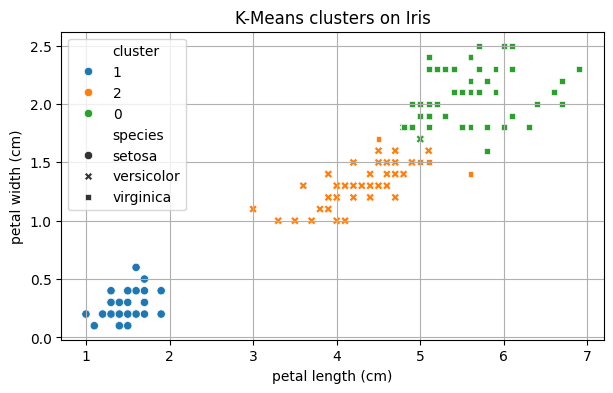

In [6]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
print('Adjusted Rand Index:', adjusted_rand_score(y, clusters))
plot_df = X.copy(); plot_df['cluster'] = clusters.astype(str); plot_df['species'] = iris.target_names[y]
sns.scatterplot(data=plot_df, x='petal length (cm)', y='petal width (cm)', hue='cluster', style='species')
plt.title('K-Means clusters on Iris')
plt.grid(True); plt.show()
